# 02 - Elo Ratings

Fit the Elo model by replaying matches chronologically, then inspect the resulting ratings and a sample prediction.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.data import load_matches, load_teams
from wcpredictor.data.preprocess import build_training_matches
from wcpredictor.models import EloModel

In [2]:
tr = build_training_matches(load_matches(config), config)
teams = load_teams(config)
elo = EloModel(config).fit(tr, track_history=True)
table = elo.ratings_table(teams)
table.head(20)

,team,rating,confederation,pot
0,France,1784.730800,UEFA,1.0
1,Netherlands,1777.150913,UEFA,1.0
2,Argentina,1713.811684,CONMEBOL,1.0
3,Germany,1690.252969,UEFA,1.0
4,England,1677.143295,UEFA,1.0
5,Brazil,1676.232052,CONMEBOL,1.0
6,Spain,1671.330300,UEFA,1.0
7,Belgium,1631.867922,UEFA,2.0
8,Italy,1613.677012,NaN,NaN
9,Soviet Union,1610.322643,NaN,NaN


## Top 15 teams by Elo

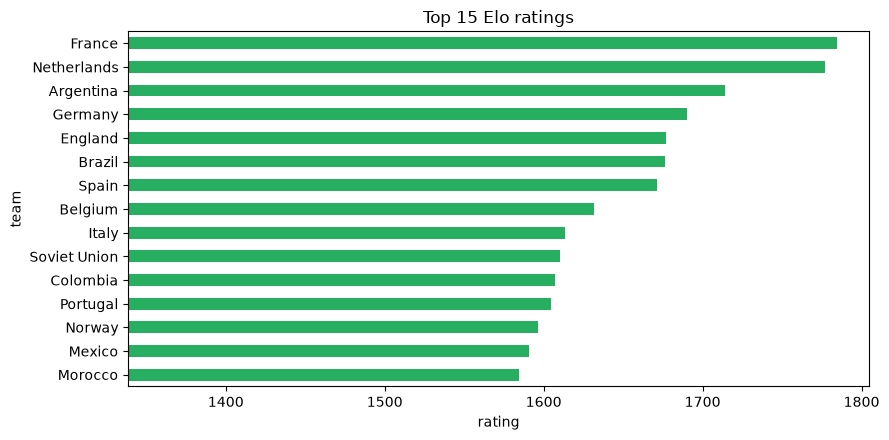

In [3]:
top = table.head(15).iloc[::-1]
ax = top.plot.barh(x='team', y='rating', legend=False, color='#27ae60')
ax.set_title('Top 15 Elo ratings'); ax.set_xlabel('rating')
ax.set_xlim(table['rating'].min() - 20, table['rating'].max() + 20)
plt.tight_layout(); plt.show()

## Average rating by confederation

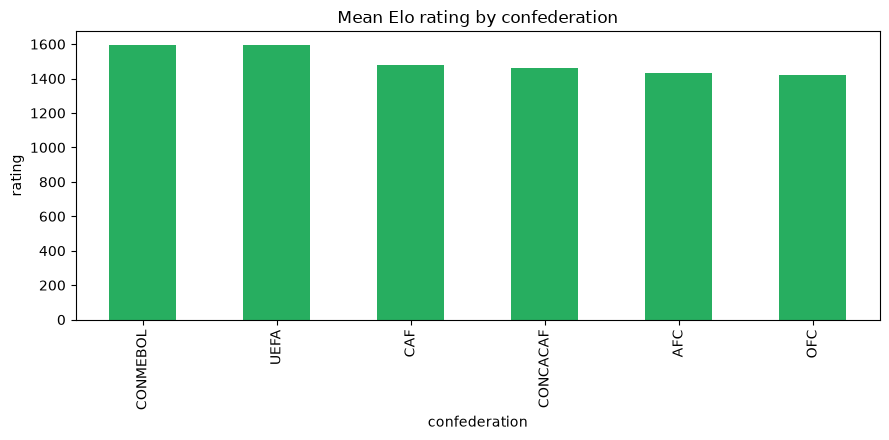

confederation
CONMEBOL    1594.635156
UEFA        1593.264384
CAF         1481.446499
CONCACAF    1461.507388
AFC         1431.903621
OFC         1419.143288
Name: rating, dtype: float64

In [4]:
by_conf = table.groupby('confederation')['rating'].mean().sort_values(ascending=False)
ax = by_conf.plot.bar(color='#27ae60')
ax.set_title('Mean Elo rating by confederation')
ax.set_ylabel('rating'); plt.tight_layout(); plt.show()
by_conf

## Sample prediction

In [5]:
pred = elo.predict_match('Brazil', 'Germany', neutral=True)
print(f'Brazil win: {pred.p_home_win:.1%}')
print(f'Draw:       {pred.p_draw:.1%}')
print(f'Germany win:{pred.p_away_win:.1%}')

Brazil win: 30.9%
Draw:       34.1%
Germany win:35.0%


## Rating evolution

Because the training data now spans real World Cup history (1930-2026) rather than a handful of synthetic years, we can watch these traditional powers' Elo ratings rise and fall across the decades.

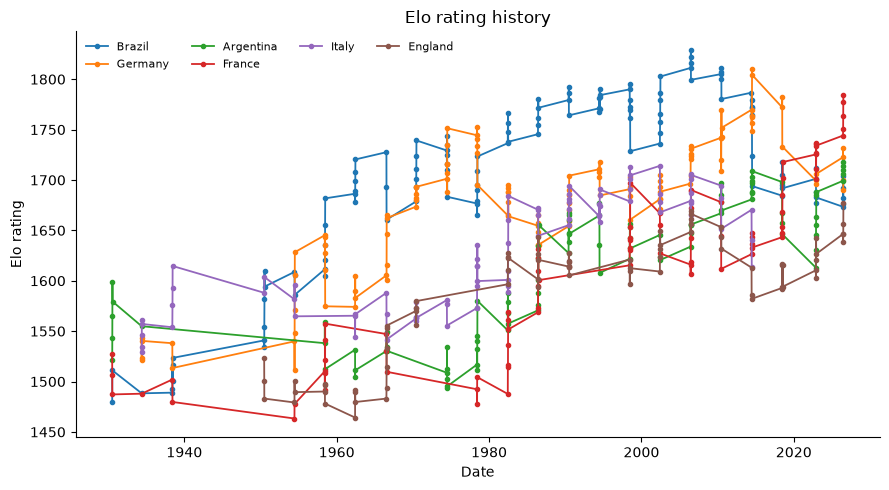

In [6]:
from wcpredictor.visualization import plot_rating_history
plot_rating_history(elo.history, ['Brazil', 'Germany', 'Argentina', 'France', 'Italy', 'England'])
plt.tight_layout(); plt.show()